<a href="https://colab.research.google.com/github/mbenedicto99/Natural-Language-Processing/blob/main/BENE_PECE_2026_AutoML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Marcos Lopes - PECE/USP

# Lazy Predict



In [1]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.8 MB/s eta 0:00:00


In [2]:
import lazypredict
from lazypredict.Supervised import LazyClassifier

In [3]:
!pip install "tqdm>=4.9.0"
from tqdm.auto import tqdm
tqdm.pandas()

import pandas as pd
import numpy as np
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pré-processamento



In [4]:
# Estas são as resenhas para a modelização de brinquedo:

corpus = [('Esse restaurante é um lixo', 0),
          ('A comida servida no inferno', 0),
          ('Senti um cheiro nauseante. Achei que era um caminhão de lixo passando. Era o meu prato.', 0),
          ('Perfeito para o seu cachorro', 1),
          ('Restaurante ótimo', 1),
          ('Restaurante horroroso. A comida é lixo em estado coloidal e o outro emprego do garçom é carcereiro de masmorra.', 0)
          ]

In [5]:
### Módulos e funções do pré-processamento ###

import itertools
from collections import Counter

import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('stopwords')
stops = nltk.corpus.stopwords.words('portuguese')

nltk.download('rslp')
raiz = nltk.stem.RSLPStemmer().stem


def tokenizar(txt: str) -> list:
    return word_tokenize(txt, language='english')


def sem_stops(lista_de_palavras: list) -> list:
    return [p for p in lista_de_palavras if p not in stops]


def limpar(lista_de_palavras: list) -> list:
    return [i.lower() for i in lista_de_palavras if i.isalpha()]


def stem(lista_de_palavras: list) -> list:
    return [raiz(i) for i in lista_de_palavras]


def pre_processar(str_texto: str) -> str:
    return ' '.join(stem(sem_stops(limpar(tokenizar(str_texto)))))


def achatar(lista: list) -> list:
    return list(itertools.chain(*lista))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


In [6]:
# Usar DataFrames não é obrigatório, mas ajuda

df = pd.DataFrame(corpus, columns=['Texto', 'Etiqueta'])
df['TextoLimpo'] = df['Texto'].progress_apply(pre_processar)  # progress_apply(): mostra uma barra de progresso
df

  0%|          | 0/6 [00:00<?, ?it/s]

,Texto,Etiqueta,TextoLimpo
0,Esse restaurante é um lixo,0,restaurant lix
1,A comida servida no inferno,0,com serv infern
2,Senti um cheiro nauseante. Achei que era um ca...,0,sent cheir nause ach caminh lix pass prat
3,Perfeito para o seu cachorro,1,perfeit cachorr
4,Restaurante ótimo,1,restaurant ótim
5,Restaurante horroroso. A comida é lixo em esta...,0,restaurant horror com lix est coloid outr empr...


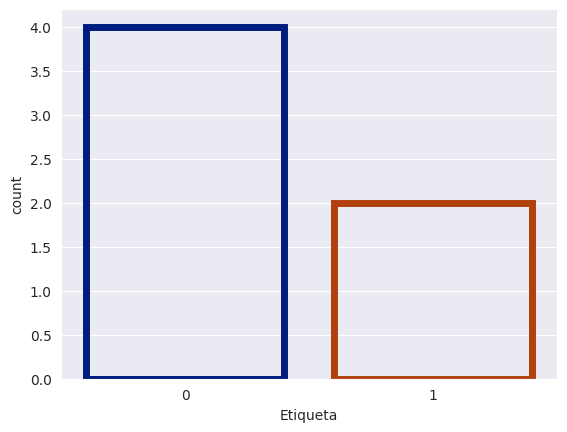

In [7]:
# Como está a distribuição das classes?

sns.set_style('darkgrid')

ax = sns.countplot(data=df, x='Etiqueta',
                   facecolor=(0, 0, 0, 0),
                   linewidth=5,
                   edgecolor=sns.color_palette('dark', 5)
                   )

# Vetorização

In [8]:
t = Tokenizer()
t.fit_on_texts(df['TextoLimpo'])  # Estabelece o vocabulário
X = t.texts_to_matrix(df['TextoLimpo'], mode='count') # Converte a lista em matriz de contagem (do Numpy)

### OPCIONAL: Para normalizar o vetor pela pontuação média, ou z-score: (x - média) / std
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

X.shape  # O formato será (n_documentos, len_vocabulário)

(6, 24)

In [9]:
X

array([[0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 1., 1., 1., 1., 1., 1., 1.]])

In [10]:
y = df['Etiqueta'].to_numpy()
y.shape

(6,)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

# Classificação

In [12]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
DummyClassifier,1.0,1.0,NaN,1.000000,1.0,1.0,0.024875
LabelPropagation,1.0,1.0,NaN,1.000000,1.0,1.0,0.020285
LGBMClassifier,1.0,1.0,NaN,1.000000,1.0,1.0,0.078472
XGBClassifier,1.0,1.0,NaN,1.000000,1.0,1.0,0.108051
LabelSpreading,1.0,1.0,NaN,1.000000,1.0,1.0,0.020332
QuadraticDiscriminantAnalysis,1.0,1.0,NaN,1.000000,1.0,1.0,0.039962
AdaBoostClassifier,0.5,0.5,NaN,0.666667,1.0,0.5,0.033237
DecisionTreeClassifier,0.5,0.5,NaN,0.666667,1.0,0.5,0.021736
BaggingClassifier,0.5,0.5,NaN,0.666667,1.0,0.5,0.043642


# Exemplo de Lazy Predict com dados reais

Vamos usar o dataset das resenhas de filmes do IMDB.

In [13]:
from keras.datasets import imdb

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
### Conferindo os dados ###

# Foram carregadas 25000 resenhas.
print(X_train.shape)

# Cada resenha é composta por um vetor de inteiros representando índices de palavras.
print(X_train[24999])

# Os dados estão numa lista de listas (cada sublista é uma resenha)
for e, i in enumerate(X_train[:3]):
    print('===== Resenha ', e, i)

(25000,)
[1, 17, 6, 194, 337, 7, 4, 204, 22, 45, 254, 8, 106, 14, 123, 4, 2, 270, 2, 5, 2, 2, 732, 2098, 101, 405, 39, 14, 1034, 4, 1310, 9, 115, 50, 305, 12, 47, 4, 168, 5, 235, 7, 38, 111, 699, 102, 7, 4, 4039, 9245, 9, 24, 6, 78, 1099, 17, 2345, 2, 21, 27, 9685, 6139, 5, 2, 1603, 92, 1183, 4, 1310, 7, 4, 204, 42, 97, 90, 35, 221, 109, 29, 127, 27, 118, 8, 97, 12, 157, 21, 6789, 2, 9, 6, 66, 78, 1099, 4, 631, 1191, 5, 2642, 272, 191, 1070, 6, 7585, 8, 2197, 2, 2, 544, 5, 383, 1271, 848, 1468, 2, 497, 2, 8, 1597, 8778, 2, 21, 60, 27, 239, 9, 43, 8368, 209, 405, 10, 10, 12, 764, 40, 4, 248, 20, 12, 16, 5, 174, 1791, 72, 7, 51, 6, 1739, 22, 4, 204, 131, 9]
===== Resenha  0 [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 3

In [15]:
### Até aqui, estamos trabalhando com as 25.000 resenhas do dataset.
### Com esses números, pode não haver memória no seu sistema (Colab ou local)
### o bastante para a classificação.

### Para usar todas resenhas disponíveis:
# x = np.concatenate((X_train, X_test))
# y = np.concatenate((y_train, y_test))

### Para impor um limite (1000 resenhas já são suficientes para comparar os modelos)
limite = 1000

x = X_train[:limite]
y = y_train[:limite]

In [16]:
d = {'ResenhaCodificada': x,'Etiqueta': y}

df = pd.DataFrame(d)
df.head()

,ResenhaCodificada,Etiqueta
0,"[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, ...",1
1,"[1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463,...",0
2,"[1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 5...",0
3,"[1, 4, 2, 2, 33, 2804, 4, 2040, 432, 111, 153,...",1
4,"[1, 249, 1323, 7, 61, 113, 10, 10, 13, 1637, 1...",0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ResenhaCodificada  1000 non-null   object
 1   Etiqueta           1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [18]:
# As resenhas estão representadas por índices de palavras.
# Aqui, optaremos por convertê-las em palavras e deixar o trabalho de vetorização para depois.

indice_de_palavra = imdb.get_word_index()
palavra_de_indice = dict([(value, key) for (key, value) in indice_de_palavra.items()])

def decodificar(resenha):
    return ' '.join([palavra_de_indice.get(i-3, '') for i in resenha])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
df['Texto'] = df['ResenhaCodificada'].progress_apply(decodificar)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [20]:
df.head()

,ResenhaCodificada,Etiqueta,Texto
0,"[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, ...",1,this film was just brilliant casting location...
1,"[1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463,...",0,big hair big boobs bad music and a giant safe...
2,"[1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 5...",0,this has to be one of the worst films of the ...
3,"[1, 4, 2, 2, 33, 2804, 4, 2040, 432, 111, 153,...",1,the at storytelling the traditional sort ma...
4,"[1, 249, 1323, 7, 61, 113, 10, 10, 13, 1637, 1...",0,worst mistake of my life br br i picked this ...


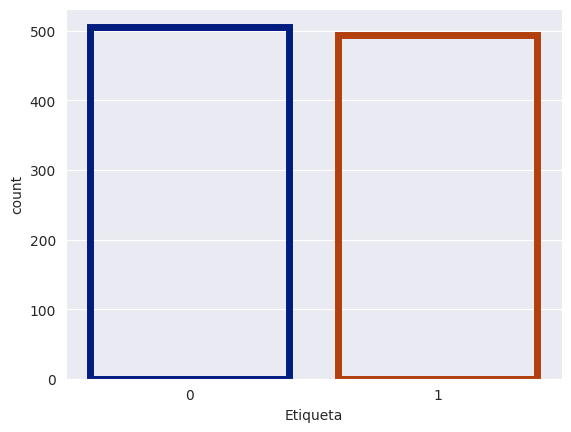

In [21]:
# Distribuição das classes

sns.set_style('darkgrid')

ax = sns.countplot(data=df, x='Etiqueta',
                   facecolor=(0, 0, 0, 0),
                   linewidth=5,
                   edgecolor=sns.color_palette('dark', 5)
                   )

In [22]:
### Modificações nas constantes e funções de pré-processamento ###


stops = nltk.corpus.stopwords.words('english')  # Atenção à língua!
from nltk.stem.snowball import SnowballStemmer
stemizador = SnowballStemmer('english')  # Atenção à língua!


def tokenizar(txt: str) -> list:
    return word_tokenize(txt, language='english')


def stem(lista_de_palavras: list) -> list:
    return [stemizador.stem(i) for i in lista_de_palavras]

In [23]:
df['TextoLimpo'] = df['Texto'].progress_apply(pre_processar)
df

  0%|          | 0/1000 [00:00<?, ?it/s]

,ResenhaCodificada,Etiqueta,Texto,TextoLimpo
0,"[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, ...",1,this film was just brilliant casting location...,film brilliant cast locat sceneri stori direct...
1,"[1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463,...",0,big hair big boobs bad music and a giant safe...,big hair big boob bad music giant safeti pin w...
2,"[1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 5...",0,this has to be one of the worst films of the ...,one worst film friend watch film target audien...
3,"[1, 4, 2, 2, 33, 2804, 4, 2040, 432, 111, 153,...",1,the at storytelling the traditional sort ma...,storytel tradit sort mani year event still see...
4,"[1, 249, 1323, 7, 61, 113, 10, 10, 13, 1637, 1...",0,worst mistake of my life br br i picked this ...,worst mistak life br br pick movi target figur...
...,...,...,...,...
995,"[1, 13, 104, 14, 131, 9, 4, 118, 2499, 50, 26,...",1,i think this still is the best routine there ...,think still best routin other like bring pain ...
996,"[1, 13, 16, 9794, 153, 154, 54, 13, 219, 14, 2...",0,i was thirteen years old when i saw this movi...,thirteen year old saw movi expect lot action s...
997,"[1, 18, 4, 1853, 13, 244, 24, 2, 19, 4, 365, 1...",1,for the record i am not with the production ...,record product way br br hidden frontier proba...
998,"[1, 4, 1165, 1279, 503, 20, 524, 47, 160, 227,...",0,the super sexy b movie actress has another bi...,super sexi b movi actress anoth bit part futur...


In [24]:
t = Tokenizer()
t.fit_on_texts(df['TextoLimpo'])  # Estabelece o vocabulário
X = t.texts_to_matrix(df['TextoLimpo'], mode='tfidf') # Converte a lista em matriz de contagem (count) ou tfidf

# Opcional: Normalização pela pontuação média
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

X.shape  # O formato será (n_documentos, len_vocabulário)

(1000, 5767)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, df['Etiqueta'], test_size=.2)

In [26]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
RandomForestClassifier,0.810,0.810924,0.902711,0.809715,0.813502,0.810,1.531475
LGBMClassifier,0.810,0.809924,0.879652,0.810000,0.810000,0.810,0.980388
BernoulliNB,0.800,0.801321,0.901861,0.799298,0.806534,0.800,0.513064
LogisticRegression,0.800,0.799320,0.862645,0.799699,0.800845,0.800,0.599541
NearestCentroid,0.795,0.795218,0.888205,0.795015,0.795389,0.795,0.509336
ExtraTreesClassifier,0.790,0.790516,0.894308,0.789937,0.791298,0.790,2.811111
XGBClassifier,0.785,0.785014,0.858643,0.785016,0.785072,0.785,1.989819
CalibratedClassifierCV,0.780,0.780512,0.858343,0.779934,0.781274,0.780,1.870608
PassiveAggressiveClassifier,0.780,0.779312,0.859944,0.779669,0.780749,0.780,0.629252


# AutoGluon

Uma biblioteca poderosa de AutoML, desenvolvida comunitariamente e com código aberto. Não somente testa diferentes modelos de classificação, como também busca ajustar os modelos. Todos os modelos ajustados ficam gravados (no Google Colab, procure por /content/AutogluonModels/) e o campeão é claramente anunciado ao final.

Por causa dos muitos testes realizados por essa biblioteca, o tempo de processamento é grande. O uso de uma GPU é altamente recomendado.

Home page: https://auto.gluon.ai/stable/index.html

Citação: Erickson, Nick, et al. "AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data." arXiv preprint arXiv:2003.06505 (2020).

In [27]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 15.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

In [ ]:
# Como a importação da biblioteca força a reinicialização do notebook,
# temos de recarregar estes módulos aqui.

import pandas as pd
from tensorflow.keras.datasets import imdb

In [ ]:
num_words = 5000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)
word_index = imdb.get_word_index()
reverse_index = {v + 3: k for k, v in word_index.items()}

def decodificar(seq):
    return ' '.join([reverse_index.get(i, '?') for i in seq])

train_df = pd.DataFrame({'Texto': [decodificar(x) for x in x_train], 'Etiqueta': y_train})
test_df = pd.DataFrame({'Texto': [decodificar(x) for x in x_test], 'Etiqueta': y_test})


In [ ]:
from autogluon.tabular import TabularPredictor

# Treinamento com limite de tempo de ajuste
predictor = TabularPredictor(label='Etiqueta').fit(
    train_df,
    presets='high_quality',
    num_stack_levels=0,
    time_limit=600  # Tempo limite para otimização (em segundos)
)

# Para treinamentos mais otimizados (e muito mais lentos), podem ser usados os
# parâmetros a seguir. Aqui, a qualidade foi ajustada para "medium_quality",
# sem limite de tempo, o que tornará o treimento muito mais lento que o anterior.
# Ainda é possível ajustar a qualidade para "high_quality" (como acima) ou "best_quality"

# predictor = TabularPredictor(label='Etiqueta').fit(train_df, presets='medium_quality')


# Avaliação
resultado = predictor.evaluate(test_df)
print(resultado)


No path specified. Models will be saved in: "AutogluonModels/ag-20260502_220722"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       7.42 GB / 12.67 GB (58.6%)
Disk Space Avail:   74.76 GB / 107.72 GB (69.4%)
Presets specified: ['high_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Beginning AutoGluon training ... Tim

{'accuracy': 0.8734, 'balanced_accuracy': np.float64(0.8734), 'mcc': np.float64(0.747005243085699), 'roc_auc': np.float64(0.9474661856), 'f1': 0.8748665638714269, 'precision': 0.8648479637301649, 'recall': 0.88512}


In [ ]:
# Usando o modelo campeão indicado ao final da célula de treinamento acima

predictor = TabularPredictor.load("/content/AutogluonModels/ag-20260502_220722")

# Predições do modelo campeão com o conjunto de testes
predicoes = predictor.predict(test_df)

print(predicoes.head())  # DataFrame no formato (Índice, Etiqueta)

0    0
1    1
2    1
3    1
4    1
Name: Etiqueta, dtype: int64


In [ ]:
# Para ver o desempenho ddos modelos testados:
# Obs.: se um limite de tempo de treinamento for usado nos parâmetros, poucos
# modelos vão aparecer aqui.

predictor.leaderboard(test_df, silent=False)

                      model  score_test  score_val eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0    LightGBMXT_BAG_L1_FULL     0.87340        NaN    accuracy        6.470643            NaN   36.307417                 6.470643                     NaN          36.307417            1       True          4
1  WeightedEnsemble_L2_FULL     0.87340        NaN    accuracy        6.474226            NaN   36.411812                 0.003583                     NaN           0.104395            2       True          6
2      LightGBM_BAG_L1_FULL     0.84132        NaN    accuracy        3.155339            NaN   19.425401                 3.155339                     NaN          19.425401            1       True          5
3         LightGBMXT_BAG_L1         NaN    0.87464    accuracy             NaN       7.417105  292.315827                      NaN                7.417105         2

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L1_FULL,0.87340,NaN,accuracy,6.470643,NaN,36.307417,6.470643,NaN,36.307417,1,True,4
1,WeightedEnsemble_L2_FULL,0.87340,NaN,accuracy,6.474226,NaN,36.411812,0.003583,NaN,0.104395,2,True,6
2,LightGBM_BAG_L1_FULL,0.84132,NaN,accuracy,3.155339,NaN,19.425401,3.155339,NaN,19.425401,1,True,5
3,LightGBMXT_BAG_L1,NaN,0.87464,accuracy,NaN,7.417105,292.315827,NaN,7.417105,292.315827,1,False,1
4,WeightedEnsemble_L2,NaN,0.87464,accuracy,NaN,7.420269,292.420222,NaN,0.003164,0.104395,2,False,3
5,LightGBM_BAG_L1,NaN,0.81432,accuracy,NaN,5.499935,182.221078,NaN,5.499935,182.221078,1,False,2


# FLAML
Fast Library for Automated Machine Learning

Home Page: https://microsoft.github.io/FLAML/

Biblioteca de código aberto da Microsoft para AutoML. Traz numerosas opções de parametrização que vão desde a escolha dos modelos até o tempo de otimização dos ajustes. O GitHub do projeto é especialmente rico em detalhes.

In [ ]:
!pip install flaml[automl]

In [ ]:
# Como a importação da biblioteca força a reinicialização do notebook,
# temos de recarregar estes módulos aqui.

import pandas as pd
from tensorflow.keras.datasets import imdb

In [ ]:
num_words = 5000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)
indice_de_palavra = imdb.get_word_index()
indice_reverso = {v + 3: k for k, v in indice_de_palavra.items()}

def decodificar(seq):
    return ' '.join([indice_reverso.get(i, '?') for i in seq])

train_df = pd.DataFrame({'Texto': [decodificar(x) for x in x_train], 'Etiqueta': y_train})
test_df = pd.DataFrame({'Texto': [decodificar(x) for x in x_test], 'Etiqueta': y_test})


In [ ]:
from sklearn.metrics import accuracy_score
from flaml import AutoML

automl = AutoML()

settings = {
    "time_budget": 300,  # Tempo em segundos para encontrar o melhor modelo
    "metric": 'accuracy',
    "task": 'classification',
    "log_file_name": 'imdb_flaml.log',
}

# Treinamento
automl.fit(X_train=train_df[['Texto']], y_train=train_df['Etiqueta'], **settings)

# Predição
predictions = automl.predict(test_df[['Texto']])

# Avaliação
print(f'Modelo campeão: {automl.best_estimator}')
print(f'Melhor parametrização: {automl.best_config}')
print(f'Acurácia: {accuracy_score(test_df['Etiqueta'], predictions):.2f}')


[flaml.automl.logger: 05-02 21:41:16] {2375} INFO - task = classification
[flaml.automl.logger: 05-02 21:41:16] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-02 21:41:16] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 05-02 21:41:17] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 05-02 21:41:17] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-02 21:41:19] {3046} INFO - Estimated sufficient time budget=21193s. Estimated necessary time budget=522s.
[flaml.automl.logger: 05-02 21:41:19] {3097} INFO -  at 3.5s,	estimator lgbm's best error=5.0000e-01,	best estimator lgbm's best error=5.0000e-01
[flaml.automl.logger: 05-02 21:41:19] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-02 21:41:21] {3097} INFO -  at 5.4s,	estimator lgbm's best error=5.0000e-01,	best estimator lgbm's best error=5.0000e-

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 05-02 21:41:23] {3097} INFO -  at 7.3s,	estimator sgd's best error=5.0000e-01,	best estimator lgbm's best error=5.0000e-01
[flaml.automl.logger: 05-02 21:41:23] {2911} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 05-02 21:41:25] {3097} INFO -  at 9.1s,	estimator lgbm's best error=5.0000e-01,	best estimator lgbm's best error=5.0000e-01
[flaml.automl.logger: 05-02 21:41:25] {2911} INFO - iteration 5, current learner sgd
[flaml.automl.logger: 05-02 21:41:25] {3097} INFO -  at 9.3s,	estimator sgd's best error=5.0000e-01,	best estimator lgbm's best error=5.0000e-01
[flaml.automl.logger: 05-02 21:41:25] {2911} INFO - iteration 6, current learner sgd
[flaml.automl.logger: 05-02 21:41:25] {3097} INFO -  at 9.4s,	estimator sgd's best error=5.0000e-01,	best estimator lgbm's best error=5.0000e-01
[flaml.automl.logger: 05-02 21:41:25] {2911} INFO - iteration 7, current learner sgd
[flaml.automl.logger: 05-02 21:41:25] {3097} INFO -  at 9.5s,	estimator sgd's 

In [ ]:
# Para ver uma lista completa dos modelos testados
# e seus respectivos resultados de acurácia:

modelos = automl.best_config_per_estimator.keys()

for m in modelos:
    # FLAML registra perdas. P/ calcular a acurácia, subtraí-las de 1:
    accuracy = 1 - automl.best_loss_per_estimator[m]

    print(f'{m.upper()}: Acurácia: {accuracy:.2f}')

print(f'\n*** Campeão: {automl.best_estimator.upper()}, com incríveis {1 - automl.best_loss:.2f} de acurácia! ***')
print('Obs.: Resultados "-inf" representam perdas infinitas. São casos em que houve algum problema com a execução do modelo.')


LGBM: Acurácia: 0.50
RF: Acurácia: 0.58
XGBOOST: Acurácia: 0.56
EXTRA_TREE: Acurácia: 0.58
XGB_LIMITDEPTH: Acurácia: -inf
SGD: Acurácia: 0.50
CATBOOST: Acurácia: 0.50
LRL1: Acurácia: -inf

*** Campeão: RF, com incríveis 0.58 de acurácia! ***
Obs.: Resultados "-inf" representam perdas infinitas. São casos em que houve algum problema com a execução do modelo.
